In [24]:
!pip install control

DEPRECATION: Loading egg at c:\users\oscar\appdata\local\programs\python\python312\lib\site-packages\jwcrypto-1.5.6-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at c:\users\oscar\appdata\local\programs\python\python312\lib\site-packages\redis-6.2.0-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at c:\users\oscar\appdata\local\programs\python\python312\lib\site-packages\websockify-0.13.0-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330

[notice] A new release of pip is available: 2

In [25]:
import control


A transfer function has the form:

𝐺(𝑠) = 𝑁(𝑠)/𝐷(𝑠)

where:
N(s) = numerator polynomial
D(s) = denominator polynomial

In [26]:
num = [5]          # Numerator coefficients
den = [1, 3, 2]    # Denominator coefficients

In [27]:
import control as ctrl
import matplotlib.pyplot as plt

G = ctrl.tf(num,den)

In [28]:
print (G)

<TransferFunction>: sys[6]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']


      5
-------------
s^2 + 3 s + 2



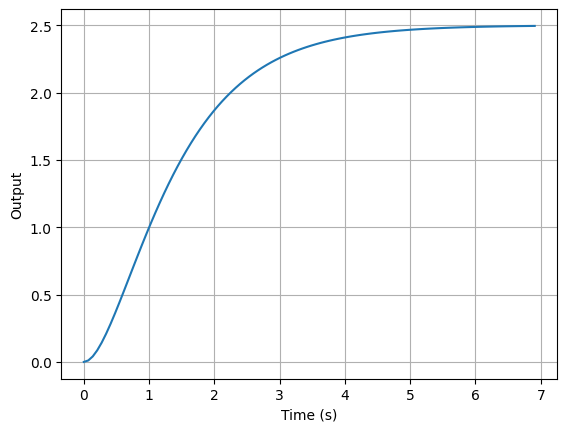

In [29]:
t, y = ctrl.step_response(G)
plt.plot(t, y)
plt.xlabel("Time (s)")
plt.ylabel("Output")
plt.grid()
plt.show()

Agentic RAG
RAG - Retrieval Augmented Generation
Agentic AI - use of agents (mini worker that specify it job in the whole process)
Langchain
crewai


In [ ]:
pip install langchain langchain-community faiss-cpu pypdf sentence-transformers

In [1]:
from langchain.document_loaders import PyPDFLoader
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain.embeddings import HuggingFaceEmbeddings
from langchain.vectorstores import FAISS

# Load PDF
loader = PyPDFLoader("short_story.pdf")
docs = loader.load()

# Split text
splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50)
chunks = splitter.split_documents(docs)

# Embeddings (local)
embeddings = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")

# Store in FAISS
vectorstore = FAISS.from_documents(chunks, embeddings)
vectorstore.save_local("faiss_index")

C:\Users\oscar\AppData\Local\Temp\ipykernel_12208\3716570502.py:15: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-huggingface package and should be used instead. To use it run `pip install -U :class:`~langchain-huggingface` and import as `from :class:`~langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")
c:\Users\oscar\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from langchain.llms import OpenAI

llm = OpenAI(
    base_url="http://localhost:1234/v1",
    api_key="lm-studio",
    temperature=0.2
)

C:\Users\oscar\AppData\Local\Temp\ipykernel_12208\1484210819.py:3: LangChainDeprecationWarning: The class `OpenAI` was deprecated in LangChain 0.0.10 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-openai package and should be used instead. To use it run `pip install -U :class:`~langchain-openai` and import as `from :class:`~langchain_openai import OpenAI``.
  llm = OpenAI(


In [3]:
from langchain.vectorstores import FAISS
import os

if not os.path.exists("faiss_index"):
    vectorstore = FAISS.from_documents(chunks, embeddings)
    vectorstore.save_local("faiss_index")
else:
    vectorstore = FAISS.load_local(
        "faiss_index",
        embeddings,
        allow_dangerous_deserialization=True
    )
retriever = vectorstore.as_retriever(search_kwargs={"k": 3})

def retrieve_docs(query):
    docs = retriever.get_relevant_documents(query)
    return "\n\n".join([doc.page_content for doc in docs])

In [4]:
from docx import Document
import os
from datetime import datetime

def create_word_doc(content, filename="generated.docx", folder="generated_docs"):
    os.makedirs(folder, exist_ok=True)

    filepath = os.path.join(folder, filename)

    doc = Document()

    # Title
    doc.add_heading("Generated Document", 0)

    # Content (split into paragraphs)
    for line in content.split("\n"):
        doc.add_paragraph(line)

    doc.save(filepath)

    return f"Document saved at: {filepath}"

In [12]:
from langchain.agents import Tool

def word_tool(query):
    # Ask LLM to generate structured content
    prompt = f"""
                Create a well-structured document based on this request:
                DO NOT output JSON.
                DO NOT output tool format.
                ONLY output clean text.
                {query}

                Format:
                - Title
                - Sections
                - Bullet points if needed
                """

    content = llm.predict(prompt)

    # Create filename dynamically
    filename = f"doc_{datetime.now().strftime('%Y%m%d_%H%M%S')}.docx"

    return create_word_doc(content, filename)

word_tool_instance = Tool(
    name="Word Document Generator",
    func=word_tool,
    description="Creates a Word document from a user request"
)

In [13]:
from langchain.agents import Tool, initialize_agent, AgentType
from langchain.memory import ConversationBufferMemory

memory = ConversationBufferMemory()

doc_retrieval_tool = Tool(
        name="Document Search",
        func=retrieve_docs,
        description="Use this to answer questions from PDFs or documents"
    )

tools = [
    word_tool_instance,
    doc_retrieval_tool
]


agent = initialize_agent(
    tools,
    llm,
    agent=AgentType.STRUCTURED_CHAT_ZERO_SHOT_REACT_DESCRIPTION,  # 🔥 more stable
    verbose=True,
    handle_parsing_errors=True,
    memory=memory,
    max_iterations=5,  # prevent infinite loops
    early_stopping_method="generate",
    agent_kwargs={
        "system_message": """
You are an intelligent AI assistant with access to tools.

AVAILABLE TOOLS:
- Document Search → for answering questions from uploaded PDFs or documents
- Word Document Generator → for creating .docx files

DECISION RULES:
1. If the question is about documents or requires context → use Document Search
2. If the user asks to create/generate/write a file → use Word Document Generator
3. If the question is general knowledge → answer directly

TOOL USAGE FORMAT:
Use this JSON format:

{
  "action": "tool name",
  "action_input": "input to the tool"
}

When you already know the answer:

{
  "final_answer": "your answer here"
}

IMPORTANT:
- Do NOT explain your reasoning
- Do NOT output anything outside JSON
- Be concise and precise
"""
    }
)



In [14]:
query = "Create a document of what is control systems and its applications."
response = agent.run(query)

print(response)



> Entering new AgentExecutor chain...
Action:
```
{
  "action": "Word Document Generator",
  "action_input": "A document explaining the concept of control systems and their various applications."
}
```
Observation: Document saved at: generated_docs\doc_20260407_114358.docx
Thought: I know what to respond
Action:
```
{
  "action": "Final Answer",
  "action_input": "A document has been created and saved as 'generated_docs\\doc_20260407_114358. docx'. This document explains the concept of control systems and their various applications."
}
```

> Finished chain.
A document has been created and saved as 'generated_docs\doc_20260407_114358. docx'. This document explains the concept of control systems and their various applications.


Create an Agent that:
1. has a tool called calculator that solve arithmetic problems
2. Wikipedia extractor
3. Document creator that creates information from the Wikipedia